# V2 LLM feature extraction — granular counts with evidence

**What this notebook tests.** The V1 features asked the LLM for coarse categorical
judgements (e.g. `narrative_coherence: simple_sentences`). Seven of the ten were
individually associated with diagnosis after multiple-testing correction, but a model
built on all ten reached CV AUC 0.687 — indistinguishable from using transcript
**length alone** (0.692). The constructs were sound; the 3-level encoding discarded
nearly all of the signal.

**V2 changes one thing:** the LLM is asked to *count observable events and quote the
evidence*, not to judge. Counts become per-100-word rates so that "said more things"
is separated from "said more things per unit of speech".

**The question:** do granular LLM features beat (a) transcript length and (b) V1?
All three outcomes — better, equal, worse — are informative. See the final block.

**Test set.** The 61 labelled test cases are never loaded here. Not for feature
design, not for model selection, not for a peek. This notebook only ever sees
`train/` (241 labelled) and `overview/` (86 unlabelled).

## Block 1 — Configuration and run metadata

Everything that would change the numbers is recorded here and written to
`run_metadata.json`: model, endpoint, prompt hash, temperature, token budget, date.
This is what makes the result reproducible without a heavyweight tracking system.

In [1]:
# helpers.py sits next to this notebook -- no install step.
# External deps once:  pip install -r ../requirements.txt

In [2]:
import json, time, hashlib, datetime, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd

from helpers import (
    MODEL_A as MODEL, BASE_URL, TEMPERATURE, MAX_TOKENS, SEED, N_CALIB,
    ZERO_SHARE_MAX, EXPECTED_PROMPT_SHA,
)

warnings.filterwarnings("ignore")

# endpoint / key / thresholds / the frozen prompt / provider / eval core all live
# in helpers.py (one flat module next to the notebooks). Everything else is inlined
# in the cell that uses it.

RUN_LLM = False            # v2_raw.jsonl is cached -> analysis-only re-run
                           # (set True to (re-)extract with MODEL from scratch)

DATA      = Path("fileDataset")
OUT       = DATA / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
RAW_PATH  = OUT / "v2_raw.jsonl"          # one JSON line per document, appended live
META_PATH = OUT / "run_metadata.json"

print(f"model      : {MODEL}")
print(f"endpoint   : {BASE_URL}")
print(f"raw output : {RAW_PATH}")
print(f"RUN_LLM    : {RUN_LLM}")


model      : qwen3.5:122b
endpoint   : https://litellm.vse.cz/v1
raw output : fileDataset/outputs/v2_raw.jsonl
RUN_LLM    : False


### The V2 prompt

Label-blind (never mentions that hidden classes exist) and domain-blind (never
mentions cognition, health or screening — even as something *not* to infer, since
that would still tell the model what the study is about).

`named_entities` and `regions_referenced` are **sets**: each distinct item listed
once. Everything else lists every occurrence.

In [3]:
from helpers import V2_PROMPT, PROMPT_SHA, assert_prompt_hash, assert_domain_blind

print(f"prompt sha256[:16] = {PROMPT_SHA}   ({len(V2_PROMPT)} chars)")
# the frozen pipeline is only valid under the prompt it was built with; assert here
# too (also catches a stale import even though helpers.py single-sources the text).
assert_prompt_hash(EXPECTED_PROMPT_SHA)
assert_domain_blind()
print("domain-blind check: OK")


prompt sha256[:16] = f52aae5d939d620e   (2428 chars)
domain-blind check: OK


In [4]:
from helpers import find_dataset

DATA = find_dataset()      # unpacks fileDataset.zip beside the notebook if needed
print("dataset dir:", DATA)


dataset dir: /Users/assylbekom/Downloads/Alzheimer-LLM-features/notebooks_preliminary/fileDataset


In [5]:
# dataset located by helpers.find_dataset() above
assert (DATA / 'train').is_dir(), DATA

## Block 2 — Load the data

241 labelled training transcripts + 86 unlabelled `overview/` transcripts = 327 docs
sent to the LLM. **Modelling uses the 241 labelled ones only**; the 86 are extracted
now so they are on disk for later stability checks or rule mining without a second run.

Surface statistics are computed here because transcript length is the confound every
LLM feature has to be measured against.

In [6]:
# 241 labelled (train/) + 86 unlabelled (overview/). test/ is NEVER read here.
def read_split(folder, label):
    return [{"file": f.name, "label": label,
             "text": f.read_text(encoding="utf-8", errors="replace").strip()}
            for f in sorted(folder.glob("*.txt"))]

rows = (read_split(DATA / "train" / "negative", 0)
        + read_split(DATA / "train" / "positive", 1)
        + read_split(DATA / "overview", None))
docs = pd.DataFrame(rows)

# surface statistics -- the length confound every LLM feature is measured against.
# n_word: whitespace tokens floored at 1 (NOT \w+); n_sent: [.!?]+ runs floored at 1.
_WORD = re.compile(r"\w+", re.UNICODE)
def surface(t):
    nw = max(1, len(t.split()))
    nt = len(set(_WORD.findall(t.lower())))
    ns = max(1, len(re.findall(r"[.!?]+", t)))
    return {"n_char": len(t), "n_word": nw, "n_type": nt, "ttr": nt / nw,
            "n_sent": ns, "mlu": nw / ns, "n_comma": t.count(",")}

docs = pd.concat([docs, docs.text.apply(lambda t: pd.Series(surface(t)))], axis=1)
SURFACE = ["n_word", "n_type", "ttr", "n_sent", "mlu", "n_comma", "n_char"]

n_lab   = int(docs.label.notna().sum())
n_unlab = int(docs.label.isna().sum())
assert (n_lab, n_unlab) == (241, 86), (n_lab, n_unlab)   # fail loudly if the split changes

for sub in ("train/negative", "train/positive", "overview"):
    print(f"  {sub:16s} {'OK' if (DATA / sub).is_dir() else 'MISSING'}")
print(f"\n{len(docs)} documents  ->  {n_lab} labelled (train) + {n_unlab} unlabelled (overview)")
print(docs.loc[docs.label.notna(), "label"].astype(int)
          .map({0: "negative", 1: "positive"}).value_counts().to_string())
print(f"median words: labelled {docs.loc[docs.label.notna(), 'n_word'].median():.0f} | "
      f"all {docs.n_word.median():.0f}")
print("test/ was not read")


  train/negative   OK
  train/positive   OK
  overview         OK

327 documents  ->  241 labelled (train) + 86 unlabelled (overview)
label
negative    171
positive     70
median words: labelled 70 | all 69
test/ was not read


## Block 3 — Provider

`LocalProvider` works, but three things break on a 122B model behind a reverse proxy:

1. **504 Bad Gateway** — a non-streamed 90-second generation looks idle to the proxy.
   Streaming keeps bytes flowing.
2. **Empty response** → `ValueError: Invalid JSON response:` — Qwen3.x reasons
   internally before answering and can spend the whole token budget doing it.
   `extra_body={"think": False}` turns that off; stripping `<think>…</think>` is the backup.
3. **The library retries rate limits only** — not timeouts, 5xx, or empty bodies.

The subclass below overrides the single method all calls funnel through. Everything
else about the library is unchanged.

In [7]:
from helpers import make_provider

# StreamingLocalProvider (streaming + think-off + transient-failure retries),
# defined once in helpers.py and shared with notebook 09.
provider = make_provider(MODEL)
print("provider ready:", type(provider).__name__)


provider ready: StreamingLocalProvider


## Block 4 — Latency probe and prompt calibration

Two gates before committing to 327 calls.

**Timing:** measures how long a real transcript actually takes. Multiply by 327 for
the wall-clock estimate.

**Quality:** run on unlabelled `overview/` documents only, and check that (a) the JSON
parses, (b) every quoted span *literally appears* in the transcript. If the model
invents evidence, the counts are fiction and nothing downstream is trustworthy.

In [8]:
# groundedness / missing-fields QC -- inlined (short, notebook-specific)
EVIDENCE_FIELDS = ["named_entities", "specific_action_verbs", "generic_verbs",
                   "locative_expressions", "hedge_spans", "deictic_spans",
                   "metacomment_spans", "diminutive_or_affective_forms", "quantity_expressions"]
REQUIRED = EVIDENCE_FIELDS + ["complete_propositions", "regions_referenced",
                              "repeated_content_lemmas", "self_corrections"]

def groundedness(obj, text):
    """Share of quoted spans that literally occur in the transcript. NaN if no spans."""
    low, hit, tot = text.lower(), 0, 0
    for f in EVIDENCE_FIELDS:
        for s in obj.get(f, []) or []:
            if isinstance(s, str) and s.strip():
                tot += 1
                hit += s.strip().lower() in low
    return hit / tot if tot else np.nan

def missing_fields(obj):
    return [f for f in REQUIRED if f not in obj]

def extract_one(text):
    return provider.text_features([text], prompt=V2_PROMPT)[0]

if RUN_LLM:
    calib = docs[docs.label.isna()].head(N_CALIB)     # unlabelled only
    t0 = time.time()
    probe = []
    for _, r in calib.iterrows():
        s = time.time()
        try:
            o = extract_one(r.text)
            probe.append({"file": r.file, "sec": time.time() - s, "ok": True,
                          "missing": missing_fields(o), "grounded": groundedness(o, r.text),
                          "n_ent": len(o.get("named_entities", []) or [])})
        except Exception as e:
            probe.append({"file": r.file, "sec": time.time() - s, "ok": False,
                          "missing": None, "grounded": np.nan, "n_ent": None,
                          "err": f"{type(e).__name__}: {e}"[:120]})
    probe = pd.DataFrame(probe)
    print(probe.to_string(index=False))
    med = probe.sec.median()
    print(f"\nmedian {med:.1f}s/doc  ->  327 docs ~ {med * 327 / 60:.0f} min")
    print(f"parsed OK        : {probe.ok.sum()}/{len(probe)}")
    print(f"mean groundedness: {probe.grounded.mean():.2f}   (want > 0.80)")
    bad = [m for m in probe.missing.dropna() if m]
    print(f"docs w/ missing fields: {len(bad)}")
    print("\n>>> GATE: if groundedness is low or parsing fails, fix the prompt before Block 5.")
else:
    print("RUN_LLM = False -- skipping.")


RUN_LLM = False -- skipping.


## Block 5 — Full extraction (resumable)

Each response is appended to `outputs/v2_raw.jsonl` and flushed immediately. Re-running
this cell skips documents already in the file, so a crash at document 180 costs you
document 180 — not the previous 179.

In [9]:
# resumable JSONL extraction -- inlined. Each response is appended and flushed
# immediately; seal_last_line() repairs a crash-truncated final line before resume.
def load_raw(path):
    out = {}
    if path.exists():
        for line in path.read_text(encoding="utf-8").splitlines():
            if line.strip():
                try:
                    rec = json.loads(line); out[rec["file"]] = rec
                except Exception:
                    pass
    return out

def seal_last_line(path):
    if path.exists() and path.stat().st_size:
        with path.open("rb+") as fh:
            fh.seek(-1, 2)
            if fh.read(1) != b"\n":
                fh.write(b"\n")

if RUN_LLM:
    seal_last_line(RAW_PATH)
    done = load_raw(RAW_PATH)
    todo = docs[~docs.file.isin(done)]
    print(f"already done: {len(done)}   remaining: {len(todo)}")
    t0 = time.time()
    with RAW_PATH.open("a", encoding="utf-8") as fh:
        for i, (_, r) in enumerate(todo.iterrows(), 1):
            rec = {"file": r.file, "label": (None if pd.isna(r.label) else int(r.label)),
                   "model": MODEL, "prompt_sha": PROMPT_SHA}
            try:
                rec["response"] = extract_one(r.text); rec["error"] = None
            except Exception as e:
                rec["response"] = None; rec["error"] = f"{type(e).__name__}: {e}"[:300]
            fh.write(json.dumps(rec, ensure_ascii=False) + "\n"); fh.flush()
            if i % 10 == 0 or i == len(todo):
                el = time.time() - t0
                print(f"  {i}/{len(todo)}  {el/60:.1f} min elapsed, "
                      f"~{el/i*(len(todo)-i)/60:.1f} min left", flush=True)

raw = load_raw(RAW_PATH)
n_ok = sum(v["response"] is not None for v in raw.values())
print(f"\nextracted: {n_ok}/{len(raw)} succeeded, {len(raw) - n_ok} failed")

META_PATH.write_text(json.dumps({
    "model": MODEL, "base_url": BASE_URL, "temperature": TEMPERATURE, "max_tokens": MAX_TOKENS,
    "streaming": True, "prompt_version": "v2", "prompt_sha256_16": PROMPT_SHA,
    "prompt_chars": len(V2_PROMPT), "n_documents_sent": len(raw), "n_succeeded": n_ok,
    "n_failed": len(raw) - n_ok, "n_labelled_for_modelling": 241, "n_unlabelled_extracted": 86,
    "test_set_used": False,
    "run_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
}, indent=2))
print(f"metadata -> {META_PATH}")



extracted: 327/327 succeeded, 0 failed
metadata -> fileDataset/outputs/run_metadata.json


## Block 6 — Quality control, before any modelling

This is the gate that decides whether the comparison means anything. Four checks:

1. **Failure rate** — how many documents produced no usable response.
2. **Groundedness** — are quoted spans real? Fabricated evidence ⇒ fabricated counts.
3. **Degeneracy** — does one value dominate a feature (>85% of docs)? V1's
   `spatial_organization_pattern` was 92% one value and carried nothing.
4. **Length confound** — r² of each feature against `n_word`, for the raw count *and*
   for the per-100-word rate. A rate still strongly tied to length is measuring
   length, not language. This is the check V1 failed.

In [10]:
ok = {f: v["response"] for f, v in raw.items() if v["response"] is not None}
print(f"usable responses: {len(ok)}/{len(raw)}  ({len(ok)/max(len(raw),1):.1%})")

gr = pd.Series({f: groundedness(o, docs.set_index('file').text[f]) for f, o in ok.items()})
print(f"\ngroundedness: mean {gr.mean():.3f} | median {gr.median():.3f} | "
      f"docs with no spans at all: {gr.isna().sum()}")
print(f"  docs below 0.5 grounded: {(gr < 0.5).sum()}")

miss = pd.Series([m for o in ok.values() for m in missing_fields(o)]).value_counts()
print(f"\nmissing fields across all docs:\n{miss.to_string() if len(miss) else '  none'}")

usable responses: 327/327  (100.0%)

groundedness: mean 0.980 | median 1.000 | docs with no spans at all: 0
  docs below 0.5 grounded: 1

missing fields across all docs:
generic_verbs                    3
locative_expressions             2
hedge_spans                      2
deictic_spans                    2
metacomment_spans                2
diminutive_or_affective_forms    2
quantity_expressions             2
complete_propositions            2
regions_referenced               2
repeated_content_lemmas          2
self_corrections                 2


### Build the feature matrix

Every count also becomes a **per-100-word rate**. Two derived ratios are added because
the V1 diagnostic pointed at them specifically: the balance of specific vs. generic
verbs, and how much of the scene (water / land / sky) the speaker refers to.

In [11]:
# raw LLM JSON -> feature matrix -- inlined. Every count becomes a per-100-word rate;
# two scale-free ratios are added (specific/generic verb balance, region breadth).
LIST_FIELDS = {"n_entities": "named_entities", "n_specific_verb": "specific_action_verbs",
               "n_generic_verb": "generic_verbs", "n_locative": "locative_expressions",
               "n_hedge": "hedge_spans", "n_deictic": "deictic_spans",
               "n_metacomment": "metacomment_spans", "n_diminutive": "diminutive_or_affective_forms",
               "n_quantity": "quantity_expressions"}
INT_FIELDS = {"n_proposition": "complete_propositions", "n_selfcorrect": "self_corrections"}

def to_row(obj):
    r = {}
    for out, key in LIST_FIELDS.items():
        v = obj.get(key) or []
        r[out] = len(v) if isinstance(v, list) else 0
    for out, key in INT_FIELDS.items():
        v = obj.get(key, 0)
        r[out] = int(v) if isinstance(v, (int, float)) else 0
    reg = obj.get("regions_referenced") or []
    r["n_region"] = len(set(reg)) if isinstance(reg, list) else 0
    rep = obj.get("repeated_content_lemmas") or []
    r["n_repeated_lemma"] = sum(1 for x in rep if isinstance(x, dict) and x.get("lemma"))
    r["repeat_mass"] = sum(int(x.get("count", 0)) for x in rep
                           if isinstance(x, dict) and str(x.get("count", "")).isdigit())
    return r

feat = pd.DataFrame([{"file": f, **to_row(o)} for f, o in ok.items()])
df = docs.merge(feat, on="file", how="inner")
COUNTS = [c for c in feat.columns if c != "file"]
for c in COUNTS:
    df[c + "_r100"] = 100 * df[c] / df["n_word"].clip(lower=1)
df["specific_verb_ratio"] = df.n_specific_verb / (df.n_specific_verb + df.n_generic_verb).clip(lower=1)
df["region_breadth"] = df.n_region / 3.0
RATES  = [c + "_r100" for c in COUNTS]
RATIOS = ["specific_verb_ratio", "region_breadth"]

print(f"feature matrix: {df.shape[0]} docs x {len(COUNTS)} counts + {len(RATES)} rates + {len(RATIOS)} ratios")
print(df[COUNTS].describe().T[["mean", "50%", "max"]].round(2).to_string())


feature matrix: 327 docs x 14 counts + 14 rates + 2 ratios
                   mean   50%   max
n_entities         0.31   0.0  18.0
n_specific_verb   10.31  11.0  21.0
n_generic_verb     1.79   1.0   8.0
n_locative         6.91   7.0  21.0
n_hedge            1.68   1.0  10.0
n_deictic          2.01   2.0  10.0
n_metacomment      0.98   1.0   7.0
n_diminutive       3.19   3.0  20.0
n_quantity         1.20   0.0  10.0
n_proposition     12.56  13.0  24.0
n_selfcorrect      0.44   0.0   5.0
n_region           2.57   3.0   3.0
n_repeated_lemma   3.62   3.0  10.0
repeat_mass        8.61   8.0  33.0


In [12]:
# --- degeneracy + length confound -----------------------------------------
lab = df[df.label.notna()].copy()
lab["label"] = lab.label.astype(int)
print(f"labelled docs available for modelling: {len(lab)}\n")

# degeneracy gate (mechanical): a count is degenerate if zero on > ZERO_SHARE_MAX
# of the labelled docs -- the ONLY automatic drop. ZERO_SHARE_MAX = 0.70 is shared
# with notebook 09 (the value the frozen pipeline was built with). High r2_len_rate
# is flagged as a length proxy, not dropped.
def r2_vs_length(col):
    x, y = lab["n_word"], lab[col]
    return np.nan if y.std() == 0 else np.corrcoef(x, y)[0, 1] ** 2

qc = pd.DataFrame({
    "zero_share":   [(lab[c] == 0).mean() for c in COUNTS],
    "r2_len_count": [r2_vs_length(c) for c in COUNTS],
    "r2_len_rate":  [r2_vs_length(c + "_r100") for c in COUNTS],
}, index=COUNTS).round(3)
qc["degenerate"] = qc.zero_share > ZERO_SHARE_MAX
qc["verdict"] = np.where(qc.degenerate, "DEGENERATE (mostly zero)",
                  np.where(qc.r2_len_rate > 0.30, "LENGTH PROXY (rate still tied to length)", "ok"))
print(qc.sort_values("r2_len_rate", ascending=False).to_string())
print("\nInterpretation: high r2_len_count is expected and fine -- that is why we compute rates.")
print("High r2_len_rate is the problem: it means the rate is still just length in disguise.")


labelled docs available for modelling: 241



                  zero_share  r2_len_count  r2_len_rate  degenerate                   verdict
n_specific_verb        0.017         0.210        0.187       False                        ok
n_region               0.087         0.172        0.113       False                        ok
n_proposition          0.029         0.565        0.054       False                        ok
n_entities             0.946         0.012        0.042        True  DEGENERATE (mostly zero)
n_locative             0.025         0.430        0.040       False                        ok
n_deictic              0.261         0.292        0.038       False                        ok
n_quantity             0.544         0.142        0.027       False                        ok
n_hedge                0.344         0.237        0.026       False                        ok
n_repeated_lemma       0.012         0.286        0.024       False                        ok
n_generic_verb         0.183         0.221        0.016     

## Block 7 — The comparison

Same protocol as the earlier notebooks so the numbers line up directly: repeated
stratified 5-fold CV (10 repeats), `LogisticRegression(class_weight="balanced")`,
**AUC as the primary metric** with a bootstrap 95% CI.

Accuracy is reported but should be ignored: the classes are 171/70, so predicting
"negative" for everything scores 0.71 while carrying zero information.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score, f1_score

from helpers import evaluate as _evaluate

y = lab.label.values

def evaluate(name, X, model=None):
    """helpers.evaluate, minus the raw-probability payload so the row goes straight
    into the results table (no paired bootstrap in this exploratory notebook)."""
    r = _evaluate(name, X, y, seed=SEED, model=model)
    r.pop("_proba", None)
    return r

res = []
res.append({"model": "Majority class", "n_feat": 0, "AUC": 0.5, "CI_low": np.nan,
            "CI_high": np.nan, "macroF1": f1_score(y, np.zeros_like(y), average="macro"),
            "balAcc": 0.5})
res.append(evaluate("Transcript length only", lab[["n_word"]].values))
res.append(evaluate("Surface stats",          lab[SURFACE].values))

# V1 categorical features (cached OutputsQwen/ extraction), for the direct comparison
v1p = next((p for p in [
    Path("OutputsQwen/train_all_feature_values.csv"),
    Path("../OutputsQwen/train_all_feature_values.csv"),
] if p.exists()), None)
if v1p is not None:
    v1 = pd.read_csv(v1p).rename(columns={"File": "file"})
    v1c = [c for c in v1.columns if c not in ("file", "Class", "raw_llm_output")]
    m1 = lab[["file"]].merge(v1[["file"] + v1c], on="file", how="left")
    if m1[v1c].notna().all(axis=1).mean() > 0.9:
        Xv1 = OneHotEncoder(handle_unknown="ignore").fit_transform(m1[v1c].fillna("missing"))
        res.append(evaluate("V1 LLM features (categorical)", Xv1,
                            LogisticRegression(max_iter=2000, class_weight="balanced")))
    else:
        print(f"note: {v1p} covers only {m1[v1c].notna().all(axis=1).mean():.0%} of docs -- skipping V1")
else:
    print("note: OutputsQwen/train_all_feature_values.csv not found -- skipping V1 row")

# V2: rates (chosen encoding) and rates + surface. Raw-count and counts+rates arms
# were part of the encoding exploration -- see the note above; not carried as rows.
res.append(evaluate("V2 rates (per 100 words)", lab[RATES + RATIOS].values))
res.append(evaluate("V2 + surface",             lab[COUNTS + RATES + RATIOS + SURFACE].values))

tf = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)
res.append(evaluate("TF-IDF char 3-5gram (reference ceiling)",
                    tf.fit_transform(lab.text),
                    LogisticRegression(max_iter=3000, class_weight="balanced")))

table = pd.DataFrame(res).sort_values("AUC", ascending=False).reset_index(drop=True)
print(table.round(3).to_string(index=False))
print("\nTF-IDF is a REFERENCE CEILING (uninterpretable), not a competing model.")
print("This is the first-pass exploration. The number that counts is the frozen primary")
print("in notebooks 09/10 (V2_STABLE + surface, 20 feat, CV AUC 0.8058). 'V2 + surface'")
print("here is the pre-stability-gate set (28 feat) and is close enough to be confused.")
table.to_csv(OUT / "v2_comparison.csv", index=False)


                                  model  n_feat   AUC  CI_low  CI_high  macroF1  balAcc
TF-IDF char 3-5gram (reference ceiling)    8375 0.867   0.816    0.911    0.758   0.753
                           V2 + surface      37 0.786   0.719    0.851    0.710   0.725
               V2 rates (per 100 words)      16 0.771   0.695    0.841    0.729   0.739
                          Surface stats       7 0.742   0.677    0.805    0.644   0.672
                 Transcript length only       1 0.693   0.618    0.764    0.606   0.639
          V1 LLM features (categorical)      41 0.693   0.617    0.764    0.614   0.625
                         Majority class       0 0.500     NaN      NaN    0.415   0.500

TF-IDF is a REFERENCE CEILING (uninterpretable), not a competing model.
This is the first-pass exploration. The number that counts is the frozen primary
in notebooks 09/10 (V2_STABLE + surface, 20 feat, CV AUC 0.8058). 'V2 + surface'
here is the pre-stability-gate set (28 feat) and is close eno

### Which individual features carry signal?

In [14]:
from scipy import stats
rows = []
for c in COUNTS + RATES + RATIOS:
    a, b = lab.loc[lab.label == 0, c], lab.loc[lab.label == 1, c]
    if lab[c].std() == 0:
        continue
    rows.append({"feature": c, "neg_mean": a.mean(), "pos_mean": b.mean(),
                 "AUC": roc_auc_score(y, lab[c]),
                 "p": stats.mannwhitneyu(a, b, alternative="two-sided").pvalue})
uni = pd.DataFrame(rows)
uni["q_BH"] = stats.false_discovery_control(uni.p, method="bh")
uni["direction"] = np.where(uni.AUC > 0.5, "higher in positive", "higher in negative")
uni["abs_AUC"] = (uni.AUC - 0.5).abs() + 0.5
print(uni.sort_values("abs_AUC", ascending=False).head(15)
        .drop(columns="abs_AUC").round(4).to_string(index=False))
print(f"\nsignificant after BH correction (q<0.05): {(uni.q_BH < 0.05).sum()} / {len(uni)}")

             feature  neg_mean  pos_mean    AUC      p   q_BH          direction
     n_specific_verb   11.6374    7.8857 0.1999 0.0000 0.0000 higher in negative
       n_proposition   13.8480   10.0429 0.2336 0.0000 0.0000 higher in negative
          n_locative    8.0351    5.0000 0.2688 0.0000 0.0000 higher in negative
     n_locative_r100   10.4504    7.7639 0.3171 0.0000 0.0000 higher in negative
 specific_verb_ratio    0.8743    0.7576 0.3422 0.0001 0.0004 higher in negative
    n_repeated_lemma    3.9415    3.0286 0.3446 0.0001 0.0004 higher in negative
      region_breadth    0.9337    0.7000 0.3449 0.0000 0.0000 higher in negative
            n_region    2.8012    2.1000 0.3449 0.0000 0.0000 higher in negative
      n_deictic_r100    2.1484    3.4652 0.6411 0.0005 0.0017 higher in positive
         repeat_mass    9.2047    7.5429 0.3710 0.0016 0.0048 higher in negative
n_specific_verb_r100   16.2674   13.7283 0.3749 0.0023 0.0059 higher in negative
 n_generic_verb_r100    2.13

## Block 8 — Plots

Two figures. The first is the whole thesis argument in one picture: every model's AUC
with its bootstrap CI, against a dashed line marking **transcript length alone** — the
bar V2 has to clear to be worth anything.

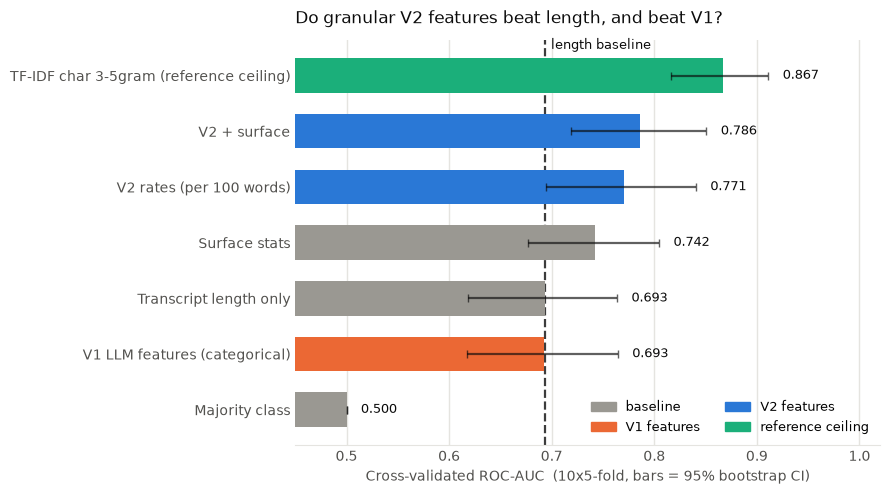

saved -> fileDataset/outputs/v2_auc_comparison.png


In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e5e4e0"
C_BASE, C_V1, C_V2, C_REF = "#9a9892", "#eb6834", "#2a78d6", "#1baf7a"

def _colour_of(name):
    if name.startswith("V2"):     return C_V2
    if name.startswith("V1"):     return C_V1
    if name.startswith("TF-IDF"): return C_REF
    return C_BASE

t = table.sort_values("AUC")
fig, ax = plt.subplots(figsize=(9, 0.52 * len(t) + 1.4))
ypos = np.arange(len(t))
ax.barh(ypos, t.AUC, height=0.62, color=[_colour_of(n) for n in t.model], zorder=3)
err = np.vstack([t.AUC - t.CI_low.fillna(t.AUC), t.CI_high.fillna(t.AUC) - t.AUC])
ax.errorbar(t.AUC, ypos, xerr=err, fmt="none", ecolor=INK, elinewidth=1.6,
            capsize=3, alpha=0.65, zorder=4)
base_auc = float(table.loc[table.model == "Transcript length only", "AUC"].iloc[0])
ax.axvline(base_auc, color=INK, ls="--", lw=1.6, alpha=0.8, zorder=2)
ax.text(base_auc + 0.006, len(t) - 0.45, "length baseline", color=INK, fontsize=9, va="center")
for i, (v, hi) in enumerate(zip(t.AUC, t.CI_high.fillna(t.AUC))):
    ax.text(hi + 0.014, i, f"{v:.3f}", va="center", fontsize=9, color=INK, zorder=6)
ax.set_yticks(ypos); ax.set_yticklabels(t.model, fontsize=10, color=INK)
ax.set_xlim(0.45, 1.02); ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.set_xlabel("Cross-validated ROC-AUC  (10x5-fold, bars = 95% bootstrap CI)", fontsize=10, color=MUTED)
ax.set_title("Do granular V2 features beat length, and beat V1?", fontsize=12.5, color=INK, pad=12, loc="left")
ax.grid(axis="x", color=GRID, lw=1, zorder=0); ax.set_axisbelow(True)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID); ax.tick_params(colors=MUTED, length=0)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in (C_BASE, C_V1, C_V2, C_REF)]
ax.legend(handles, ["baseline", "V1 features", "V2 features", "reference ceiling"],
          loc="lower right", frameon=False, fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(OUT / "v2_auc_comparison.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("saved ->", OUT / "v2_auc_comparison.png")


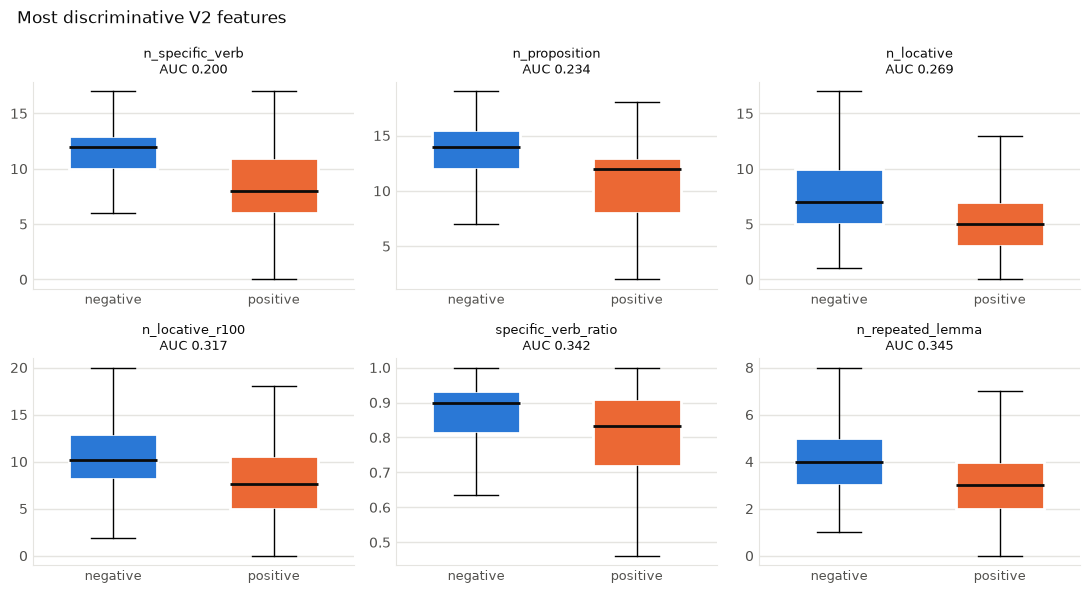

saved -> fileDataset/outputs/v2_distributions.png


In [16]:
top6 = (uni.assign(d=(uni.AUC - 0.5).abs())
           .sort_values("d", ascending=False).feature.head(6).tolist())
fig, axes = plt.subplots(2, 3, figsize=(11, 6))
for axi, c in zip(axes.ravel(), top6):
    a, b = lab.loc[lab.label == 0, c], lab.loc[lab.label == 1, c]
    bp = axi.boxplot([a, b], patch_artist=True, widths=0.55, showfliers=False,
                     medianprops=dict(color=INK, lw=2))
    for patch, col in zip(bp["boxes"], (C_V2, C_V1)):
        patch.set_facecolor(col); patch.set_edgecolor("white"); patch.set_linewidth(2)
    axi.set_xticklabels(["negative", "positive"], fontsize=9, color=MUTED)
    axi.set_title(f"{c}\nAUC {uni.loc[uni.feature == c, 'AUC'].iloc[0]:.3f}", fontsize=9.5, color=INK)
    axi.grid(axis="y", color=GRID, lw=1); axi.set_axisbelow(True)
    for s in ("top", "right"): axi.spines[s].set_visible(False)
    for s in ("left", "bottom"): axi.spines[s].set_color(GRID)
    axi.tick_params(colors=MUTED, length=0)
fig.suptitle("Most discriminative V2 features", fontsize=12.5, color=INK, x=0.02, ha="left")
plt.tight_layout()
plt.savefig(OUT / "v2_distributions.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("saved ->", OUT / "v2_distributions.png")


## Block 9 — Verdict

All three outcomes are publishable findings. What matters is stating which one
happened, and what it implies for the next step.

In [17]:
def get(name):
    m = table[table.model == name]
    return float(m.AUC.iloc[0]) if len(m) else np.nan

a_len  = get("Transcript length only")
a_v1   = get("V1 LLM features (categorical)")
a_v2   = max(get("V2 rates (per 100 words)"), get("V2 + surface"))
a_ref  = get("TF-IDF char 3-5gram (reference ceiling)")
best   = table.loc[table.AUC.idxmax(), "model"]

print(f"length baseline ......... {a_len:.3f}")
print(f"V1 categorical .......... {a_v1:.3f}")
print(f"V2 (best encoding) ...... {a_v2:.3f}")
print(f"TF-IDF ceiling .......... {a_ref:.3f}")
print(f"best overall ............ {best}\n")

print(f"groundedness {gr.mean():.2f} | extraction success {len(ok)}/{len(raw)} | "
      f"{(uni.q_BH < 0.05).sum()} features significant after BH\n")

if np.isnan(a_v1):
    print("V1 row unavailable — compare V2 against the length baseline only.")
elif a_v2 > a_v1 + 0.03 and a_v2 > a_len + 0.03:
    print("VERDICT: V2 > V1 and > length.")
    print("  The V1 result was an encoding failure, not a construct failure — asking for")
    print("  counts and evidence recovers signal that the 3-level labels destroyed.")
    print("  Next: rerun extraction with a second seed/model to measure feature stability,")
    print("  then freeze the pipeline before the test set is ever opened.")
elif abs(a_v2 - a_v1) <= 0.03 and a_v2 > a_len + 0.03:
    print("VERDICT: V2 ≈ V1, both above length.")
    print("  Granularity did not add much, but both genuinely beat length — so the LLM is")
    print("  measuring something real and cheap categorical labels suffice.")
    print("  Next: ask whether the remaining gap to TF-IDF is lexical detail the schema misses.")
elif a_v2 <= a_len + 0.03:
    print("VERDICT: V2 does not beat transcript length.")
    print("  This is a real, reportable finding: on this corpus LLM-extracted counts add")
    print("  nothing over simply how much the person said. Check the QC table above — if")
    print("  rate features still show high r2 against n_word, the features ARE length.")
    print("  Next: either the constructs need rethinking, or the honest thesis claim is that")
    print("  interpretable LLM features underperform surface and lexical baselines here.")
else:
    print("VERDICT: V2 < V1.")
    print("  Counting is noisier than judging on short transcripts. Worth checking whether")
    print("  low groundedness or truncated responses explain the drop before concluding.")

print(f"\nGap to the TF-IDF ceiling: {a_ref - a_v2:+.3f}")
print("That gap is the price of interpretability — quantifying it is itself a thesis result.")

print("\n" + "=" * 70)
print("TEST SET: untouched. The 61 labelled test cases were never loaded by this")
print("notebook. They stay sealed until the pipeline is frozen — one evaluation, once.")
print("=" * 70)

length baseline ......... 0.693
V1 categorical .......... 0.693
V2 (best encoding) ...... 0.786
TF-IDF ceiling .......... 0.867
best overall ............ TF-IDF char 3-5gram (reference ceiling)

groundedness 0.98 | extraction success 327/327 | 16 features significant after BH

VERDICT: V2 > V1 and > length.
  The V1 result was an encoding failure, not a construct failure — asking for
  counts and evidence recovers signal that the 3-level labels destroyed.
  Next: rerun extraction with a second seed/model to measure feature stability,
  then freeze the pipeline before the test set is ever opened.

Gap to the TF-IDF ceiling: +0.080
That gap is the price of interpretability — quantifying it is itself a thesis result.

TEST SET: untouched. The 61 labelled test cases were never loaded by this
notebook. They stay sealed until the pipeline is frozen — one evaluation, once.
